In [8]:
from typing import Dict, List

from model_ranking import (
    get_summary_results,
    per_source_model_results,
    per_target_consis_result_type,
    per_target_performance_result_type,
    cmb_consistency_score_weighted_average,
    to_target_transfer_correlations,
    correlation_table,
    to_target_transfer_correlations_with_norm,
    plot_alpha_sweep_specific_norm,
)

In [2]:
data_mapping = {
    "EPFL": "E",
    "Hmito": "H",
    "Rmito": "R",
    "VNC": "V",
}
consis_keys={
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
consis_keys_bckg = {
    "EPFL": "EI_consis_bckg",
    "Hmito": "EI_consis_bckg",
    "Rmito": "EI_consis_bckg",
    "VNC": "EI_consis_bckg",
}

In [3]:
result_folders_StoT={
    "EPFL": "predictions",
    "Hmito": "predictions",
    "Rmito": "predictions",
    "VNC": "predictions",
}

per_target_norms_StoT: Dict[str, List[None]] = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}

perf_key_StoT = "F1_eval"
approach_StoT = None
base_result_path_StoT = "/g/kreshuk/talks/model_ranking_results/AdaptiveBatchNorm/Mitochondria/train_mode_stats"

In [4]:
result_folders_StoS={
    "EPFL": "P_full",
    "Hmito": "P_full",
    "Rmito": "P_full",
    "VNC": "P_full",
}

per_target_norms_StoS: Dict[str, List[str]] = {
    "EPFL": ["Normalize"],
    "Hmito": ["Normalize"],
    "Rmito": ["Normalize"],
    "VNC": ["Normalize"],
}

perf_key_StoS = "hard_f1"
approach_StoS = "consistency"
#base_result_path_StoS = "/scratch/talks/consistency_results/patch_segmentation/mitochondria"
base_result_path_StoS = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

In [5]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-012", "a012-015", 'a015-02'],
}
consis_postfix="median"
perf_postfix="median"
targets = ["EPFL", "Hmito", "Rmito", "VNC"]
#targets = ["EPFL"]
sources = ["EPFL", "Hmito", "Rmito", "VNC"]
#sources = ["Hmito"]

In [6]:
model_set: Dict[str, List[str]] = {
    "EtoE": ["E_model5", "E_model_NA2", "E_model_Res1"],
    "EtoH": ["EtoHm_model5", "EtoHm_model_NA2", "EtoHm_model_Res1"],
    "EtoR": ["EtoRm_model5", "EtoRm_model_NA2", "EtoRm_model_Res1"],
    "EtoV": ["EtoV_model5", "EtoV_model_NA2", "EtoV_model_Res1"],
    "HtoE": ["HmtoE_model4", "HmtoE_model_NA2", "HmtoE_model_Res1"],
    "HtoH": ["Hm_model4", "Hm_model_NA2", "Hm_model_Res1"],
    "HtoR": ["HmtoRm_model4", "HmtoRm_model_NA2", "HmtoRm_model_Res1"],
    "HtoV": ["HmtoV_model4", "HmtoV_model_NA2", "HmtoV_model_Res1"],
    "RtoE": ["RmtoE_model4", "RmtoE_model_NA2", "RmtoE_model_Res1"],
    "RtoH": ["RmtoHm_model4", "RmtoHm_model_NA2", "RmtoHm_model_Res1"],
    "RtoR": ["Rm_model4", "Rm_model_NA2", "Rm_model_Res1"],
    "RtoV": ["RmtoV_model4", "RmtoV_model_NA2", "RmtoV_model_Res1"],
    "VtoE": ["VtoE_model2", "VtoE_model_NA2", "VtoE_model_Res1"],
    "VtoH": ["VtoHm_model2", "VtoHm_model_NA2", "VtoHm_model_Res1"],
    "VtoR": ["VtoRm_model2", "VtoRm_model_NA2", "VtoRm_model_Res1"],
}

In [7]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    per_source_forg_consistency = {}
    per_source_forg_performance = {}
    for source in sources:
        transfer = f"{data_mapping[source]}to{data_mapping[target]}"
        if transfer not in model_set:
            continue
        
        if source == target:
            base_result_path = base_result_path_StoS
            result_folders = result_folders_StoS
            per_target_norms = per_target_norms_StoS
            perf_key = perf_key_StoS
            approach = approach_StoS
        else:
            base_result_path = base_result_path_StoT
            result_folders = result_folders_StoT
            per_target_norms = per_target_norms_StoT
            perf_key = perf_key_StoT
            approach = approach_StoT

        for model in model_set[transfer]:
            consis_str, _, NA_perf = get_summary_results(
                source_data=[source],
                target_data=[target],
                selected_augmentations=selected_augmentations,
                consis_keys=consis_keys,
                result_folders=result_folders,
                source_models={source: model},
                selected_norms=per_target_norms,
                perf_key=perf_key,
                per_target_norms=True,
                approach=approach,
                consis_postfix=consis_postfix,
                perf_postfix=perf_postfix,
                summary_results_postfix=summary_results_postfix,
                base_seg_dir=base_result_path,
            )
            per_source_forg_consistency.update(
                per_source_model_results(
                    consis_str, 
                    source_models={source: model}, 
                ))
            per_source_forg_performance.update(
                per_source_model_results(
                    NA_perf, 
                    source_models={source: model},
                ))
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: EPFL


100%|██████████| 1/1 [00:00<00:00,  5.12it/s]


Source: EPFL


100%|██████████| 1/1 [00:00<00:00,  4.74it/s]


Source: EPFL


...

100%|██████████| 1/1 [00:00<00:00,  6.24it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00,  6.77it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00,  6.19it/s]


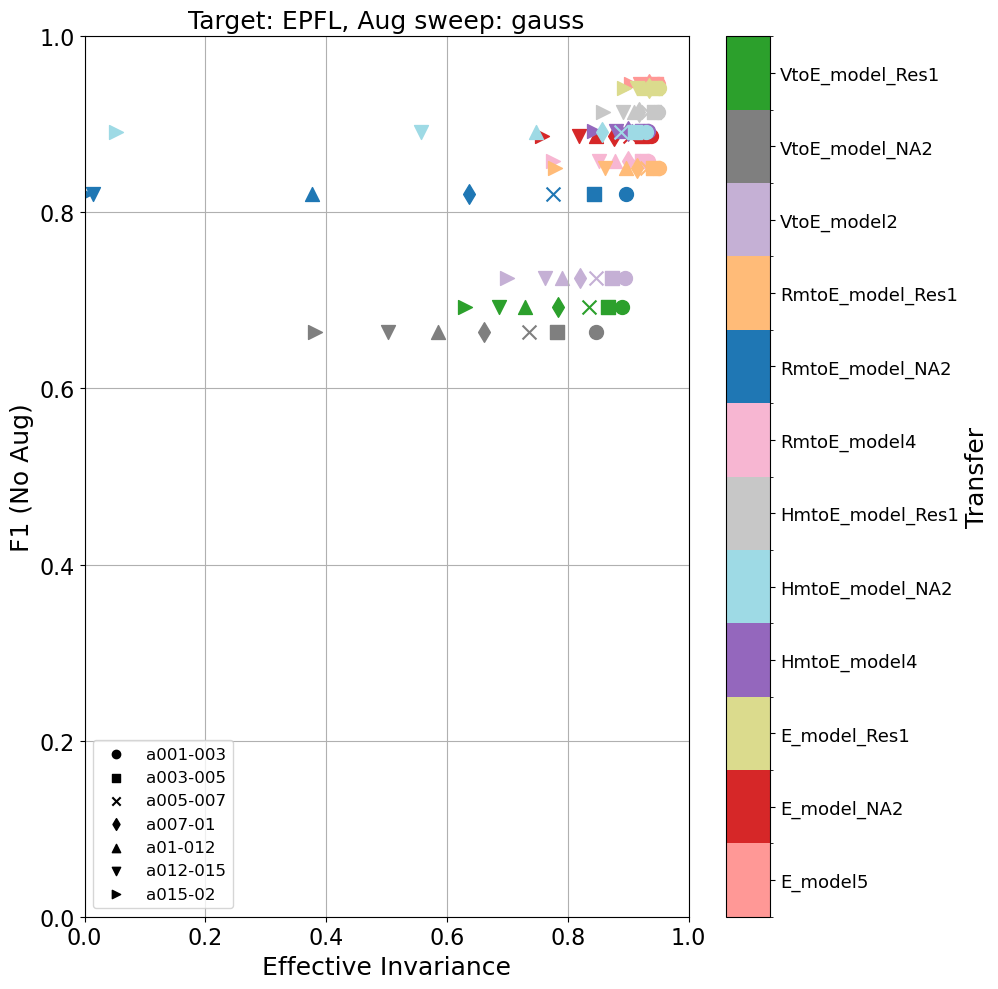

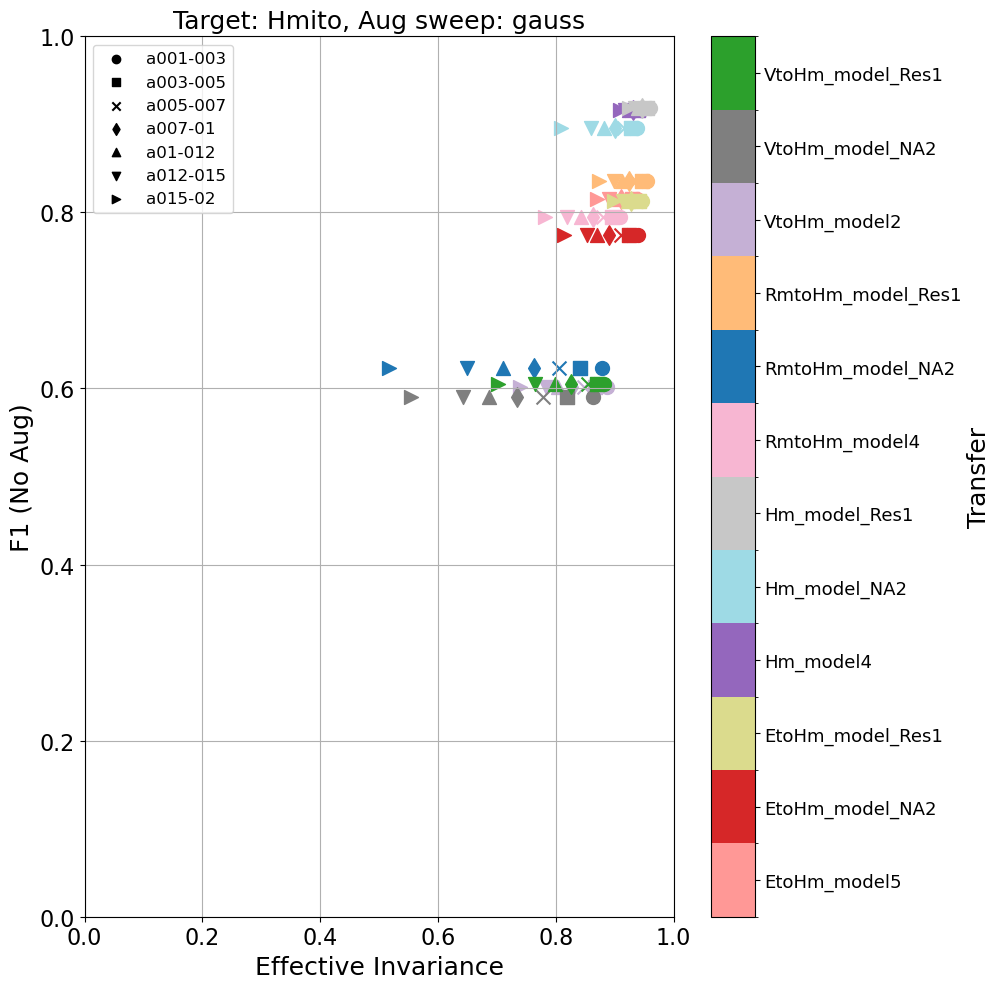

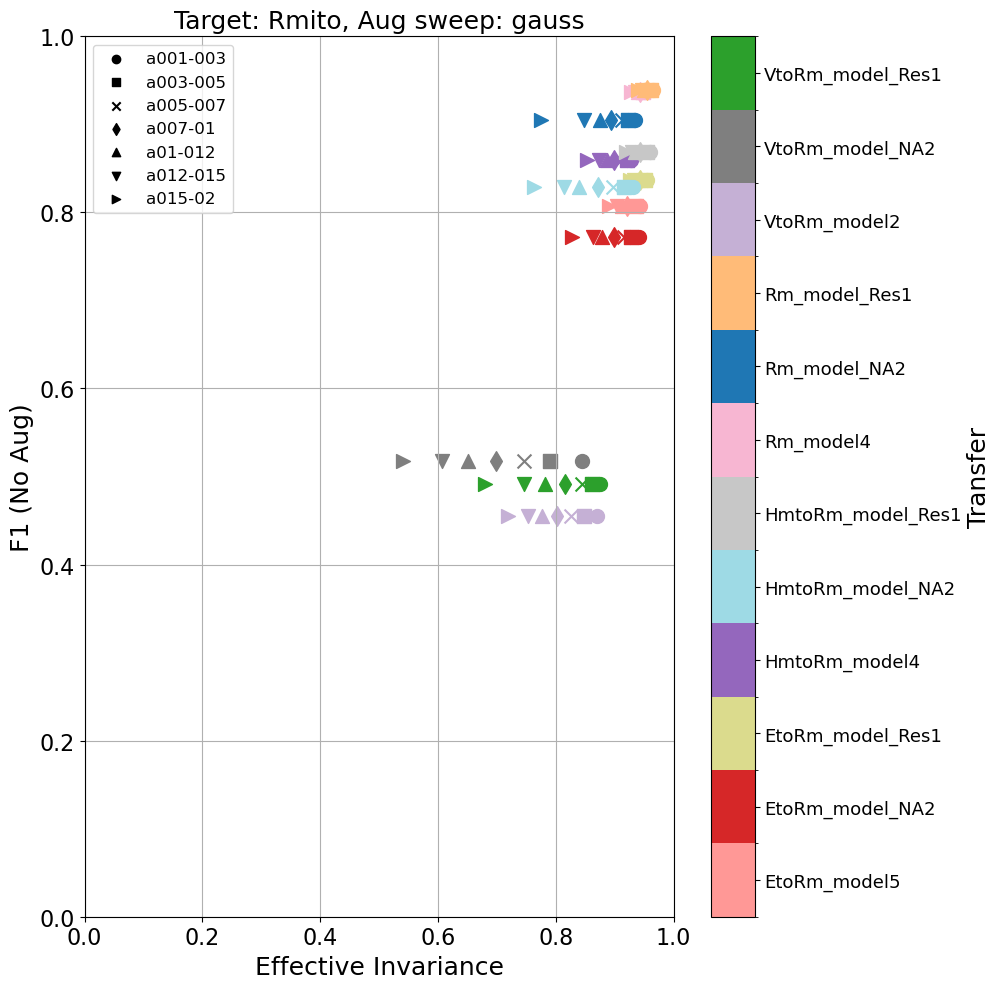

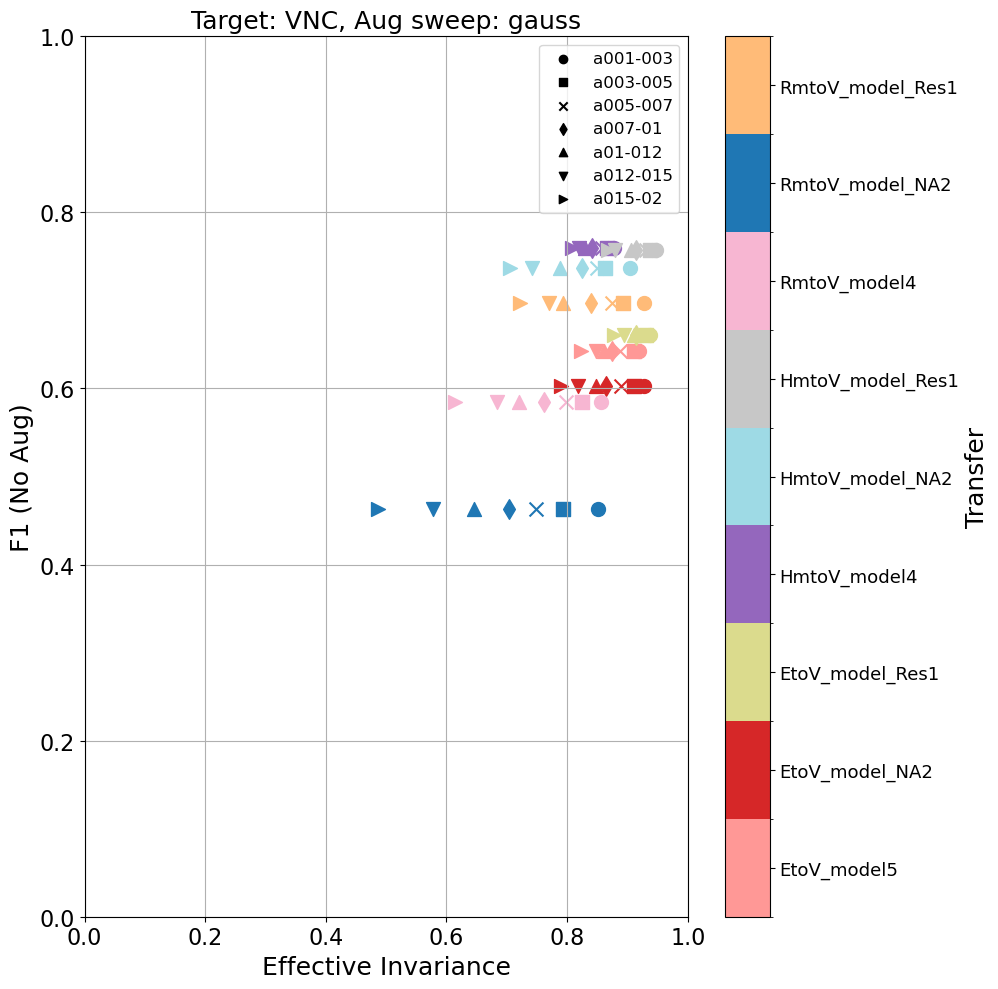

In [9]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [10]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
    perturbation_key="gauss"
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

gauss: a001-003
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.91     0.00   0.75        0.01  0.64     0.00
     Hmito    0.92     0.00   0.83        0.00  0.67     0.00
     Rmito    0.92     0.00   0.74        0.01  0.58     0.01
     VNC      0.54     0.13   0.40        0.29  0.28     0.35
gauss: a003-005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.86     0.00   0.89        0.00  0.76     0.00
     Hmito    0.91     0.00   0.88        0.00  0.73     0.00
     Rmito    0.89     0.00   0.76        0.01  0.61     0.02
     VNC      0.59     0.09   0.40        0.26  0.28     0.35
gauss: a005-007
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.82     0.00   0.88        0.00  0.73     0.00
     Hmito    0.90    

In [11]:
per_target_bckg_consistency: per_target_consis_result_type= {}
per_target_bckg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}
    for source in sources:
        transfer = f"{data_mapping[source]}to{data_mapping[target]}"
        if transfer not in model_set:
            continue
        
        if source == target:
            base_result_path = base_result_path_StoS
            result_folders = result_folders_StoS
            per_target_norms = per_target_norms_StoS
            perf_key = perf_key_StoS
            approach = approach_StoS
        else:
            base_result_path = base_result_path_StoT
            result_folders = result_folders_StoT
            per_target_norms = per_target_norms_StoT
            perf_key = perf_key_StoT
            approach = approach_StoT

        for model in model_set[transfer]:
            consis_str, _, NA_perf = get_summary_results(
                source_data=[source],
                target_data=[target],
                selected_augmentations=selected_augmentations,
                consis_keys=consis_keys_bckg,
                result_folders=result_folders,
                source_models={source: model},
                selected_norms=per_target_norms,
                perf_key=perf_key,
                per_target_norms=True,
                approach=approach,
                consis_postfix=consis_postfix,
                perf_postfix=perf_postfix,
                summary_results_postfix=summary_results_postfix,
                base_seg_dir=base_result_path,
            )
            per_source_bckg_consistency.update(
                per_source_model_results(
                    consis_str, 
                    source_models={source: model}, 
                ))
            per_source_bckg_performance.update(
                per_source_model_results(
                    NA_perf, 
                    source_models={source: model},
                ))
    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 22.54it/s]


Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 23.25it/s]


Source: EPFL


...

100%|██████████| 1/1 [00:00<00:00, 22.16it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 22.03it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 24.04it/s]


In [12]:
per_target_cmb_consistency = cmb_consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
    perturbation_key="gauss",
)

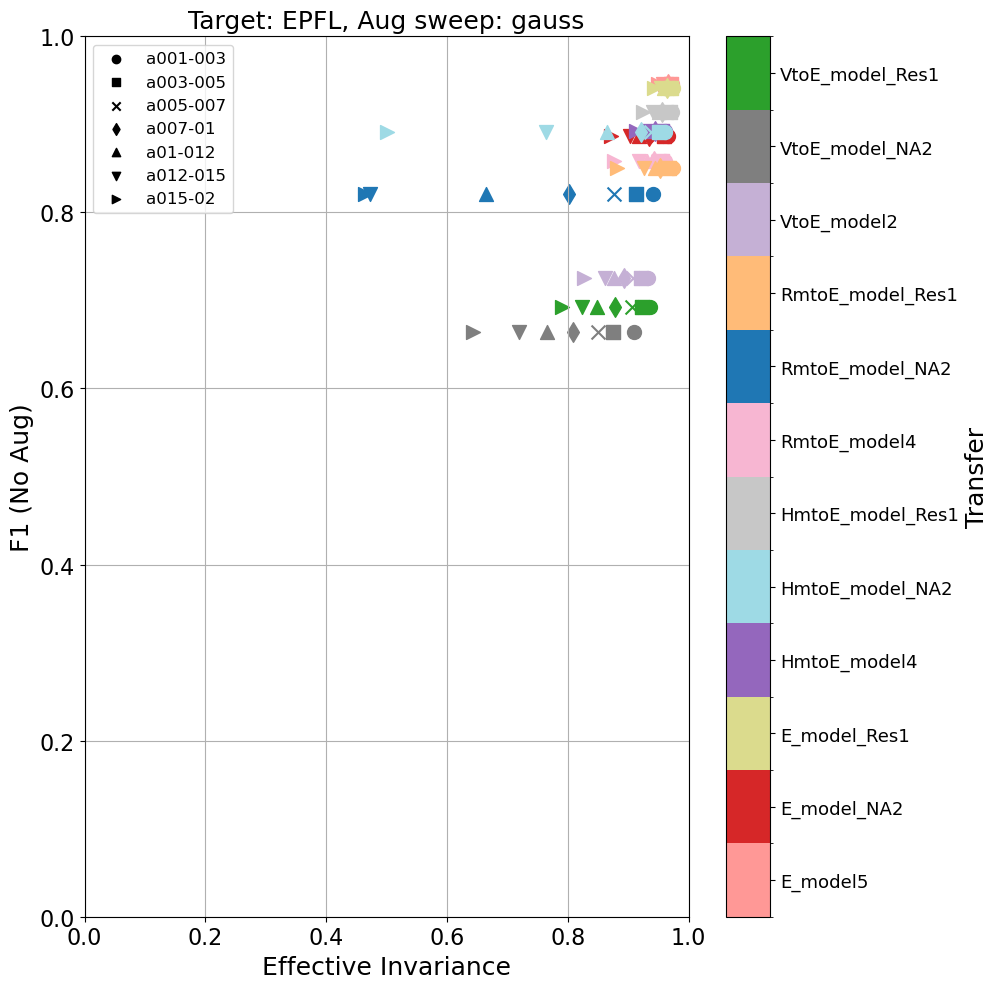

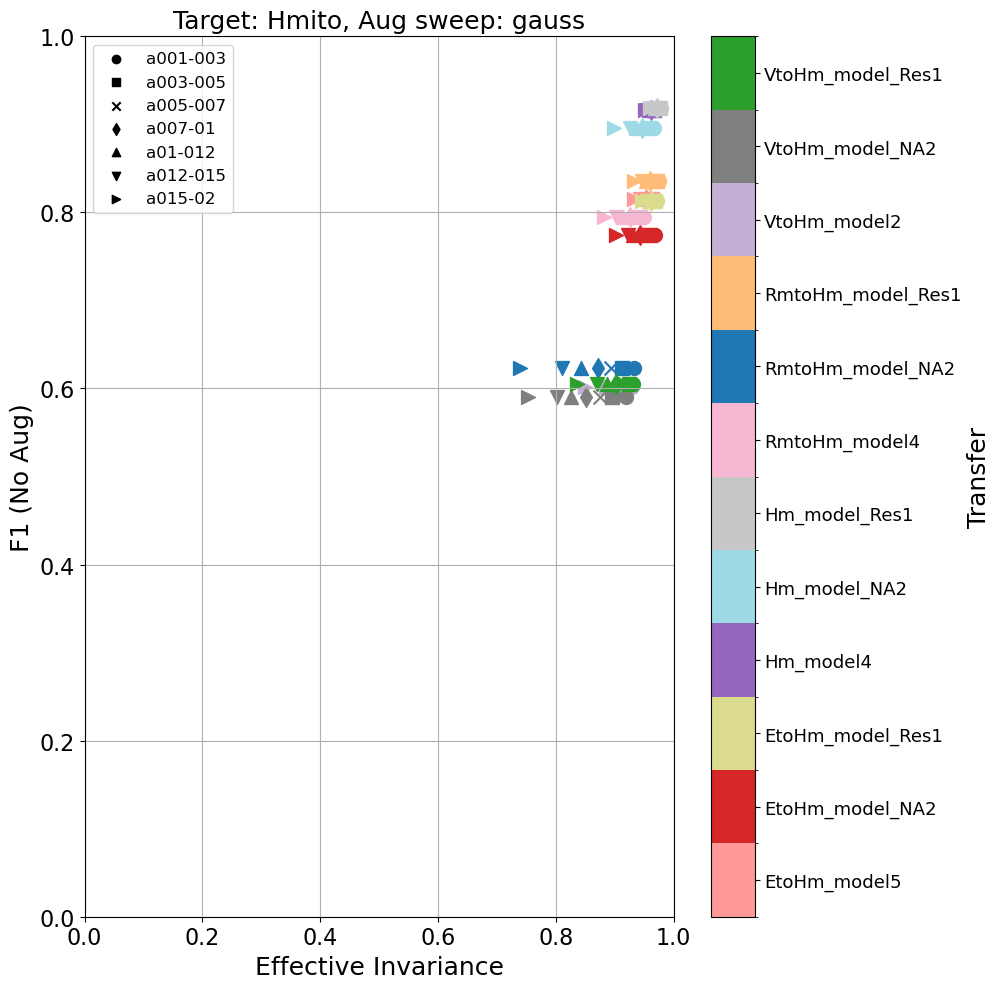

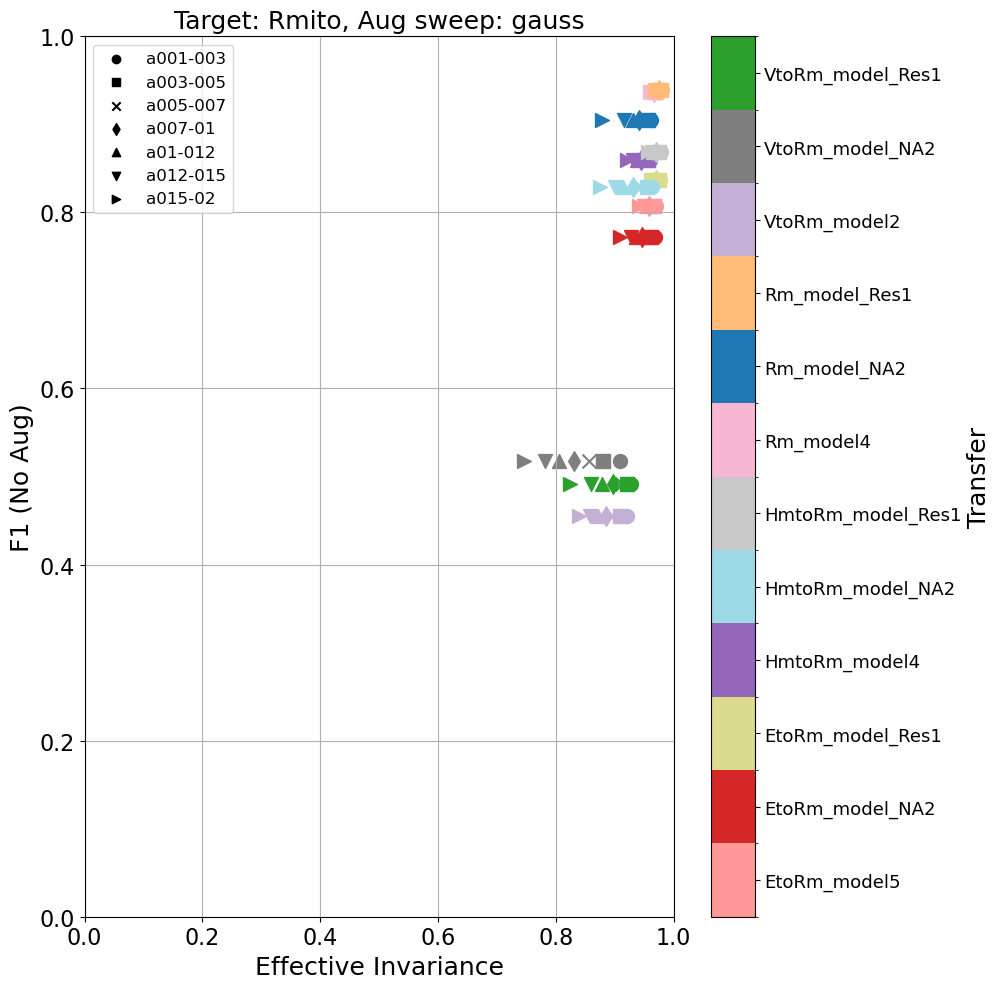

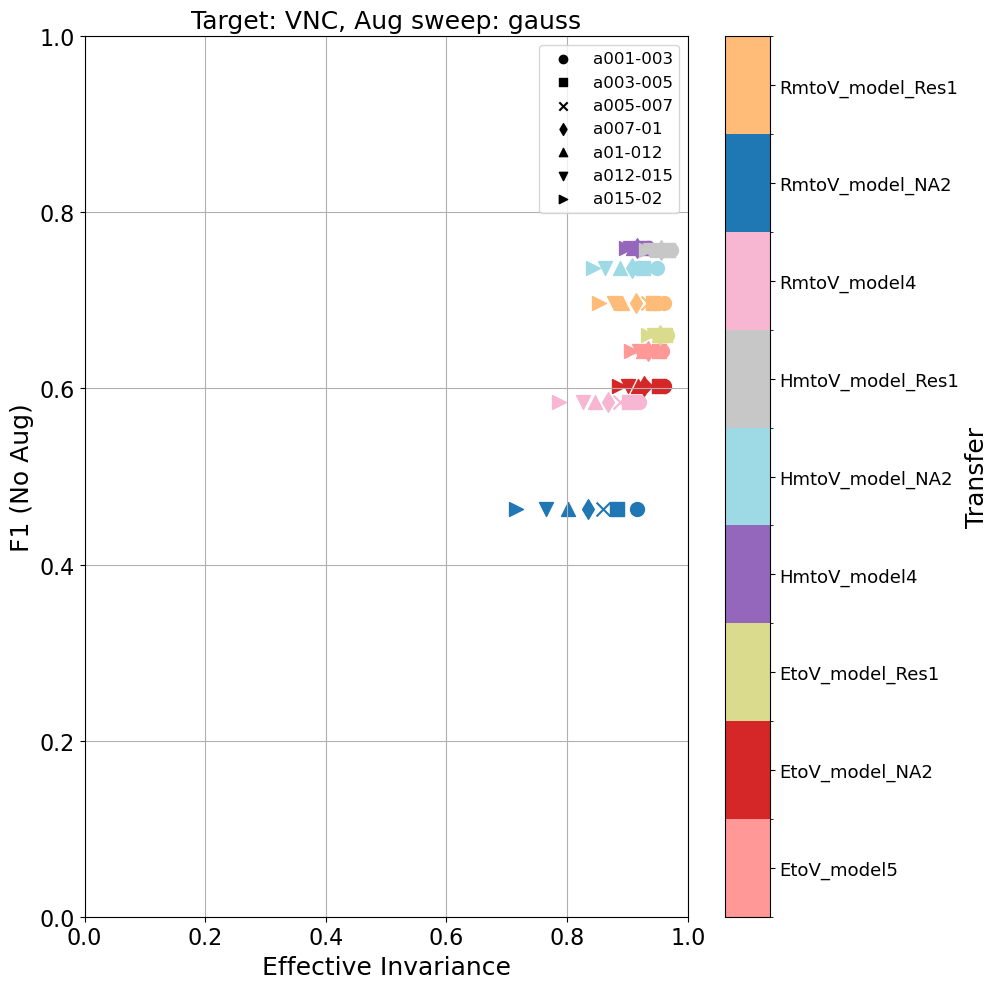

In [13]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [14]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_cmb_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
    perturbation_key="gauss"
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

gauss: a001-003
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.93     0.00   0.80        0.01  0.67     0.01
     Hmito    0.93     0.00   0.85        0.00  0.73     0.00
     Rmito    0.92     0.00   0.71        0.01  0.55     0.01
     VNC      0.57     0.11   0.45        0.22  0.33     0.26
gauss: a003-005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.89     0.00   0.87        0.00  0.70     0.00
     Hmito    0.92     0.00   0.88        0.00  0.73     0.00
     Rmito    0.89     0.00   0.76        0.01  0.61     0.00
     VNC      0.62     0.07   0.42        0.28  0.33     0.26
gauss: a005-007
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.85     0.00   0.88        0.01  0.73     0.00
     Hmito    0.91    

# Save Results

In [16]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_Normalize']
        else:
            per_target_performance[target][model] = performance

In [17]:
per_target_consistency_a001_a003: Dict[str, Dict[str,float]] = {}
per_target_consistency_a003_a005: Dict[str, Dict[str,float]] = {}
per_target_consistency_a005_a007: Dict[str, Dict[str,float]] = {}
per_target_consistency_a007_a01: Dict[str, Dict[str,float]] = {}
per_target_consistency_a01_a012: Dict[str, Dict[str,float]] = {}
per_target_consistency_a012_a015: Dict[str, Dict[str,float]] = {}
per_target_consistency_a015_a02: Dict[str, Dict[str,float]] = {}
for target, per_model_consistency in per_target_cmb_consistency.items():
    per_target_consistency_a001_a003[target] = {}
    per_target_consistency_a003_a005[target] = {}
    per_target_consistency_a005_a007[target] = {}
    per_target_consistency_a007_a01[target] = {}
    per_target_consistency_a01_a012[target] = {}
    per_target_consistency_a012_a015[target] = {}
    per_target_consistency_a015_a02[target] = {}
    for model, consistency in per_model_consistency.items():
        per_target_consistency_a001_a003[target][model] = consistency['norm_Normalize']['gauss'][0]
        per_target_consistency_a003_a005[target][model] = consistency['norm_Normalize']['gauss'][1]
        per_target_consistency_a005_a007[target][model] = consistency['norm_Normalize']['gauss'][2]
        per_target_consistency_a007_a01[target][model] = consistency['norm_Normalize']['gauss'][3]
        per_target_consistency_a01_a012[target][model] = consistency['norm_Normalize']['gauss'][4]
        per_target_consistency_a012_a015[target][model] = consistency['norm_Normalize']['gauss'][5]
        per_target_consistency_a015_a02[target][model] = consistency['norm_Normalize']['gauss'][6]
        #per_target_consistency_a01_a02[target][model] = consistency['norm_Normalize']['gauss'][4]


In [ ]:
# import json
# from typing import Any
# import os
# from model_ranking import convert_numpy_types
# save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/AdabN"
# if not os.path.exists(save_path):
#     os.makedirs(save_path)
# with open(os.path.join(save_path, "transfer_AdaBN_train_GaussSweep_CMB_05f_05b_EI_scores_with_NORM.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "transfer_scores": convert_numpy_types(per_target_cmb_consistency),
#     }
#     json.dump(results, f, indent=4)

In [25]:
consistency_results = [
    per_target_consistency_a001_a003,
    per_target_consistency_a003_a005,
    per_target_consistency_a005_a007,
    per_target_consistency_a007_a01,
    per_target_consistency_a01_a012,
    per_target_consistency_a012_a015,
    per_target_consistency_a015_a02,
]

for consistency_result, augmentation in zip(consistency_results, selected_augmentations['gauss']):
    per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations(
        targets,
        consistency_result,
        per_target_performance,
    )
    df = correlation_table(per_target_KT, per_target_SP, per_target_PE, targets)
    print(f"Gauss: {augmentation}")
    print(df)

Gauss: a001-003
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.93     0.00   0.80        0.00  0.67     0.00
     Hmito    0.93     0.00   0.85        0.00  0.73     0.00
     Rmito    0.92     0.00   0.71        0.02  0.55     0.01
     VNC      0.57     0.11   0.45        0.24  0.33     0.25
Gauss: a003-005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.89     0.00   0.87        0.00  0.70     0.00
     Hmito    0.92     0.00   0.88        0.00  0.73     0.00
     Rmito    0.89     0.00   0.76        0.01  0.61     0.01
     VNC      0.62     0.07   0.42        0.26  0.33     0.28
Gauss: a005-007
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.85     0.00   0.88        0.00  0.73     0.00
     Hmito    0.91    